<a href="https://colab.research.google.com/github/cyanm002-maker/Deep_learning_project/blob/main/Dog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
# Sckit-learn data sep
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
# Open cv
import cv2
import tensorflow as tf
from tensorflow import keras
from keras import layers
from functools import partial

In [2]:
import warnings
warnings.filterwarnings('ignore')
AUTO = tf.data.experimental.AUTOTUNE

# Loading dataset

In [21]:
from zipfile import ZipFile
data_path =  "/content/drive/MyDrive/project only/dog-breed-identification.zip" # Corrected path based on previous ls output
with ZipFile(data_path, 'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [22]:
# EDA

In [23]:
df = pd.read_csv('labels.csv')
df.head()

,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


In [25]:
df.shape

(10222, 2)

In [26]:
df['breed'].nunique()

120

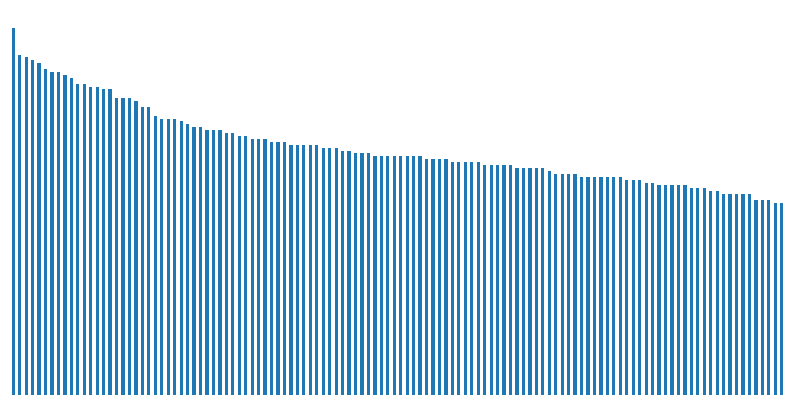

In [27]:
plt.figure(figsize=(10, 5))
df['breed'].value_counts().plot.bar()
plt.axis('off')
plt.show()


In [28]:
df['filepath'] = 'train/' + df['id'] + '.jpg'
df.head()

,id,breed,filepath
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull,train/000bec180eb18c7604dcecc8fe0dba07.jpg
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo,train/001513dfcb2ffafc82cccf4d8bbaba97.jpg
2,001cdf01b096e06d78e9e5112d419397,pekinese,train/001cdf01b096e06d78e9e5112d419397.jpg
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick,train/00214f311d5d2247d5dfe4fe24b2303d.jpg
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever,train/0021f9ceb3235effd7fcde7f7538ed62.jpg


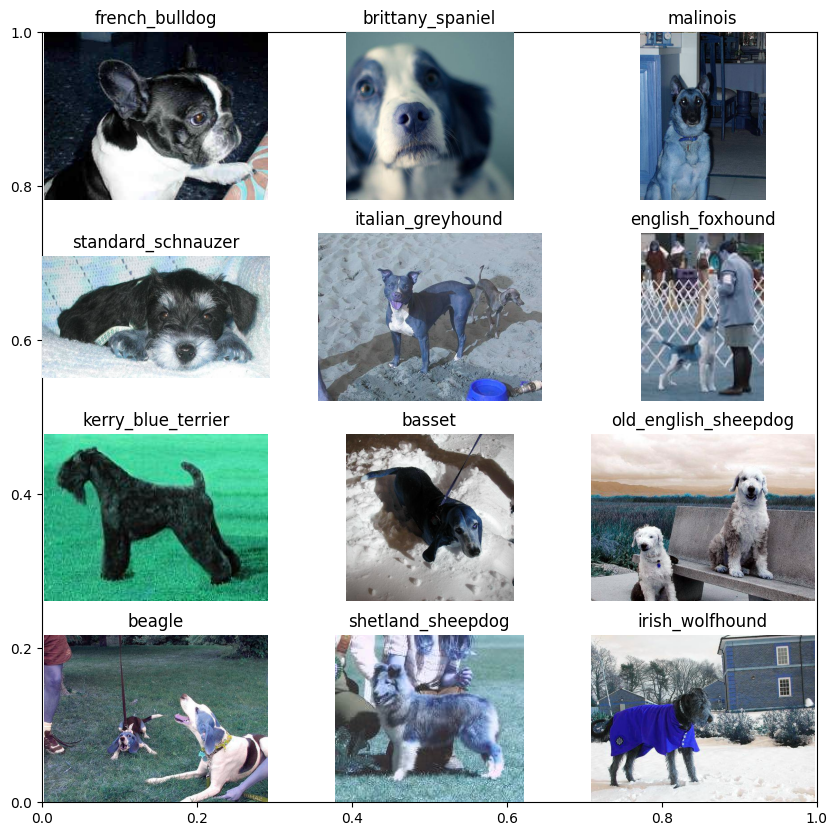

In [29]:
plt.subplots(figsize=(10, 10))
for i in range(12):
    plt.subplot(4, 3, i+1)


    k = np.random.randint(0, len(df))
    img = cv2.imread(df.loc[k, 'filepath'])
    plt.imshow(img)
    plt.title(df.loc[k, 'breed'])
    plt.axis('off')
plt.show()

In [30]:
le = LabelEncoder()
df['breed'] = le.fit_transform(df['breed'])
df.head()

,id,breed,filepath
0,000bec180eb18c7604dcecc8fe0dba07,19,train/000bec180eb18c7604dcecc8fe0dba07.jpg
1,001513dfcb2ffafc82cccf4d8bbaba97,37,train/001513dfcb2ffafc82cccf4d8bbaba97.jpg
2,001cdf01b096e06d78e9e5112d419397,85,train/001cdf01b096e06d78e9e5112d419397.jpg
3,00214f311d5d2247d5dfe4fe24b2303d,15,train/00214f311d5d2247d5dfe4fe24b2303d.jpg
4,0021f9ceb3235effd7fcde7f7538ed62,49,train/0021f9ceb3235effd7fcde7f7538ed62.jpg


In [32]:
features = df['filepath']
target = df['breed']

X_train, X_val, Y_train, Y_val = train_test_split(features, target,
                                      test_size=0.25,
                                      random_state=10)

X_train.shape, X_val.shape #75:25

((7666,), (2556,))

# Image Augmentation

In [33]:
import albumentations as A

transforms_train = A.Compose([
    A.VerticalFlip(p=0.2),
    A.HorizontalFlip(p=0.7),
    A.CoarseDropout(p=0.5),
    A.RandomGamma(p=0.5),
    A.RandomBrightnessContrast(p=1)
])

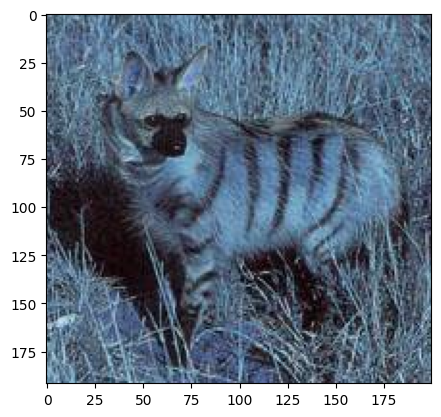

In [34]:
img = cv2.imread('train/00792e341f3c6eb33663e415d0715370.jpg') #this is a method of reading photo
plt.imshow(img)
plt.show()

# Applying argumentation in this photos

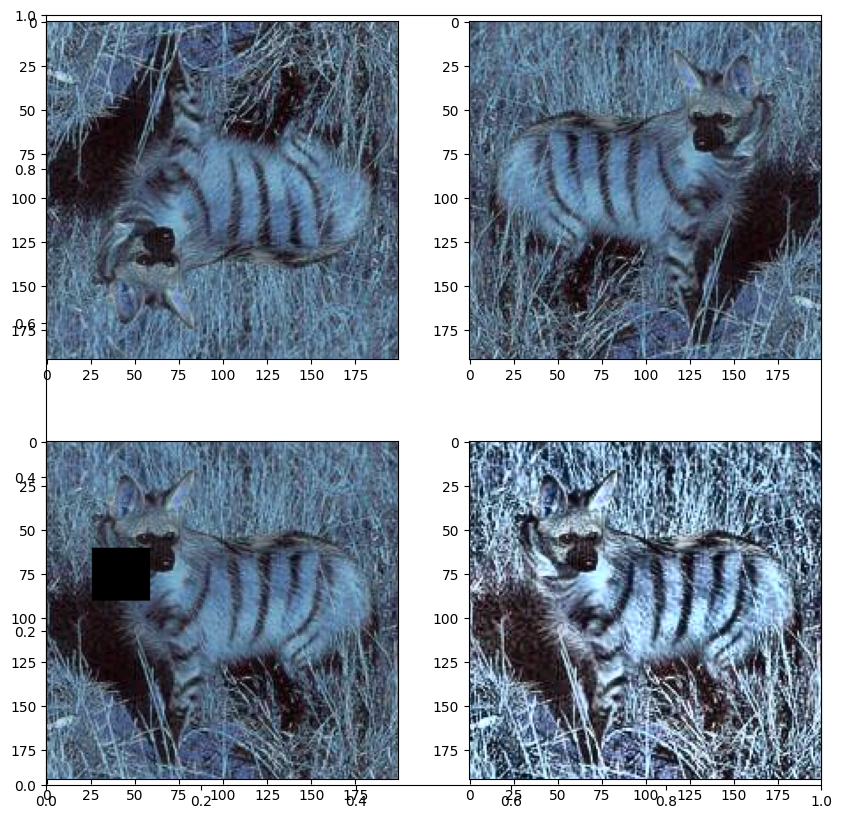

In [35]:
augments = [A.VerticalFlip(p=1), A.HorizontalFlip(p=1),
            A.CoarseDropout(p=1), A.CLAHE(p=1)]
plt.subplots(figsize=(10,10))
for i,aug in enumerate(augments):
  plt.subplot(2,2,i+1)
  aug_img = aug(image=img)['image']
  plt.imshow(aug_img)
plt.show()

In [38]:
def aug_fn(img):
  aug_date = transforms_train(image=img)
  aug_img = aug_date['image']
  return aug_img

@tf.function
def process_data(img,label):
  aug_img = tf.numpy_function(aug_fn,[img],Tout=tf.float32)
  # aug_img.set_shape((224,224,3))
  return img,label

def decode_image(filepath,label=None):
  img = tf.io.read_file(filepath)
  img = tf.image.decode_jpeg(img)
  img = tf.image.resize(img,[128,128])

  if label == None:
    return img
  return img,tf.one_hot(indices=label,depth=120,dtype=tf.float32)

In [51]:
train_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_train, Y_train))
    .map(decode_image, num_parallel_calls=AUTO)
    .map(partial(process_data), num_parallel_calls=AUTO)
    .batch(32)
    .prefetch(AUTO)
)

val_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_val, Y_val))
    .map(decode_image, num_parallel_calls=AUTO)
    .batch(32)
    .prefetch(AUTO)
)

In [41]:
for img, label in train_ds.take(1):
  print(img.shape, label.shape)

(32, 128, 128, 3) (32, 120)


# Model Building transfer layer

In [52]:
from tensorflow.keras.applications.inception_v3 import InceptionV3
from google.colab import files
import numpy as np
import cv2
import tensorflow as tf
import io

pre_trained_model = InceptionV3(
    input_shape=(128, 128, 3),
    weights='imagenet',
    include_top=False
)

# --- Functions for dog/not dog prediction system ---

def preprocess_uploaded_image(image_bytes, target_size=(128, 128)):
    """
    Preprocesses an image from bytes for model prediction.
    """
    img_array = np.array(bytearray(image_bytes), dtype=np.uint8)
    img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError("Could not decode image from bytes.")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert BGR to RGB
    img = cv2.resize(img, target_size)
    img = np.expand_dims(img, axis=0) # Add batch dimension
    img = img / 255.0 # Normalize pixel values to [0, 1]
    return img

def predict_uploaded_photo(trained_model, label_encoder, threshold=0.5):
    """
    Uploads a photo, preprocesses it, and uses the trained model
    to predict if it's a dog and if so, its breed.
    This function assumes 'trained_model' (your 'model' object) and
    'label_encoder' (your 'le' object) are available in the global scope
    or passed correctly.
    """
    uploaded = files.upload() # Colab file upload widget
    if not uploaded:
        return "No file uploaded."

    for filename, content in uploaded.items():
        print(f"Uploaded file: {filename}")
        try:
            processed_img = preprocess_uploaded_image(content, target_size=(128, 128))

            # Predict using the trained model
            predictions = trained_model.predict(processed_img)
            predicted_class_idx = np.argmax(predictions[0])
            confidence = np.max(predictions[0])

            if confidence > threshold:
                predicted_breed = label_encoder.inverse_transform([predicted_class_idx])[0]
                return f"This appears to be a dog of breed '{predicted_breed}' with {confidence*100:.2f}% confidence."
            else:
                return f"This does not appear to be a dog (or model is highly uncertain). Max confidence: {confidence*100:.2f}%."

        except Exception as e:
            return f"An error occurred during prediction for {filename}: {e}"
    return "Prediction process completed."

# To use this system, run `predict_uploaded_photo(model, le)` after the model has been trained.
# Ensure 'model' (your trained Keras model) and 'le' (your fitted LabelEncoder) are in scope.

# Model depth no of layers

In [45]:
len(pre_trained_model.layers)

311

# Freeze Pre-Trained Layers

In [46]:
# Unfreeze the layers from 'mixed5' onwards for fine-tuning
unfreeze_from_layer = 'mixed5'

set_trainable = False
for layer in pre_trained_model.layers:
  if layer.name == unfreeze_from_layer:
    set_trainable = True
  if set_trainable:
    layer.trainable = True
  else:
    layer.trainable = False

last_layer = pre_trained_model.get_layer('mixed7')
print('last layer output shape: ', last_layer.output.shape)
last_output = last_layer.output

last layer output shape:  (None, 6, 6, 768)


In [47]:
# Model Architecture
x = layers.Flatten()(last_output)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
x = layers.BatchNormalization()(x)
output = layers.Dense(120, activation='softmax')(x)

model = keras.Model(pre_trained_model.input, output)

# Model Compilation for fine-tuning
# Use a very low learning rate for fine-tuning to avoid destroying learned weights
model.compile(
	optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # Lower learning rate
	loss=keras.losses.CategoricalCrossentropy(from_logits=True),
	metrics=[tf.keras.metrics.AUC()]
)

In [48]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

class myCallback(tf.keras.callbacks.Callback):
	def on_epoch_end(self, epoch, logs={}):
		if logs.get('val_auc') is not None and logs.get('val_auc') > 0.99:
			print('\n Validation accuracy has reached upto 90% so, stopping further training.')
			self.model.stop_training = True

es = EarlyStopping(patience=3,
                monitor='val_auc',
                restore_best_weights=True,
                mode='max')

lr = ReduceLROnPlateau(monitor='val_loss',
					patience=2,
					factor=0.5,
					verbose=1)

# Train model

In [49]:
# Increase epochs and remove the strict myCallback for initial fine-tuning,
# but keep EarlyStopping and ReduceLROnPlateau.
# We'll rely on 'es' to stop training if val_auc plateaus.
history = model.fit(train_ds,
                    validation_data=val_ds,
                    epochs=100, # Increased epochs
                    verbose=1,
                    callbacks=[es, lr]) # Removed myCallback for now

Epoch 1/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 55s 152ms/step - auc: 0.5867 - loss: 4.9695 - val_auc: 0.6444 - val_loss: 4.8757 - learning_rate: 0.0010
Epoch 2/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 21s 86ms/step - auc: 0.6918 - loss: 4.5488 - val_auc: 0.6542 - val_loss: 4.7804 - learning_rate: 0.0010
Epoch 3/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 19s 81ms/step - auc: 0.7453 - loss: 4.3087 - val_auc: 0.6532 - val_loss: 4.8017 - learning_rate: 0.0010
Epoch 4/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 20s 84ms/step - auc: 0.7825 - loss: 4.1083 - val_auc: 0.6901 - val_loss: 4.6210 - learning_rate: 0.0010
Epoch 5/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 21s 88ms/step - auc: 0.8135 - loss: 3.9179 - val_auc: 0.6743 - val_loss: 4.7309 - learning_rate: 0.0010
Epoch 6/50
239/240 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - auc: 0.8374 - loss: 3.7582
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
240/240 ━━━━━━━━━━━━━━━━━━━━ 18s 77ms/step - auc: 0.8400 - loss: 3.7343 - val_auc: 0.6611 - val_loss: 5.0010 - learning_r

In [54]:
print(predict_uploaded_photo(model, le))

Saving images.jfif to images (1).jfif
Uploaded file: images (1).jfif
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
This does not appear to be a dog (or model is highly uncertain). Max confidence: 46.35%.


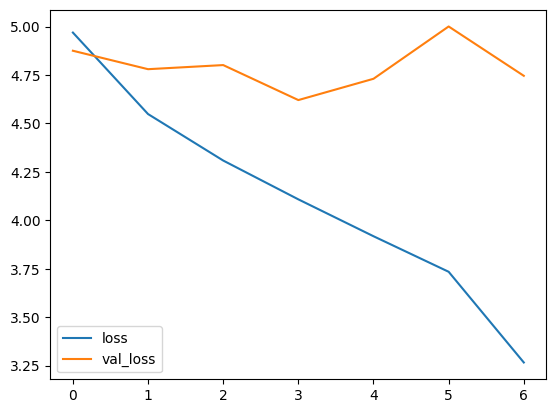

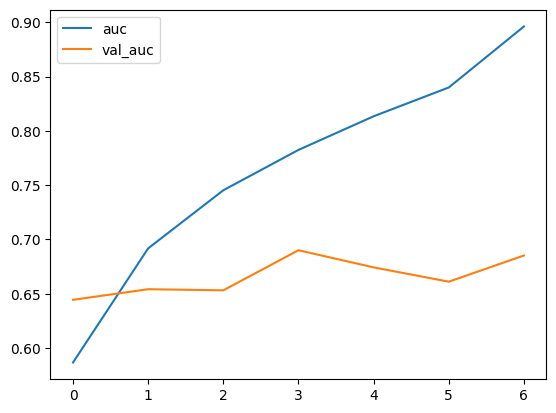

In [50]:
history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot()
history_df.loc[:, ['auc', 'val_auc']].plot()
plt.show()